<a href="https://colab.research.google.com/github/ShymaShameer/A-B-Testing-of-Button-Variants-using-Chi-Square-Test/blob/main/Eniac_Hypothesis_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Case study: Eniac’s A/B Test**




Four versions of the button were taken for testing:

A - White “SHOP NOW”

B - Red “SHOP NOW”

C - White “SEE DEALS”

D - Red “SEE DEALS”


Metric chosen included

**Click-through rate (CTR) for the homepage**.

* CTR = Total number of clicks / total visits to the page.

* Selected as a measure of the initial ability of a website element to lead use to interact with it.

**Drop-off rate for the linked page.**
* represents the percentage of visitors who initiate a conversion process (such as a purchase or sign-up) but do not complete it.
* serves as an indicator of how engaged users remain at any point in the conversion process.
* A lower drop-off rate is preferable, as it suggests a higher likelihood of users completing the desired action.

**Homepage-return rate (HRR) for the category pages.**
* Measures how often users return to the homepage after clicking the button.
* Similarly to the drop-off rate, this metric helps us infer whether users are finding what they need after clicking the tested element.
* If they frequently return to the homepage, it suggests they might not be finding the desired information on the linked page.
* HRR serves as a useful indicator of how well the button leads users to the desired content.
* Ideally, we want to minimize the homepage-return rate, which would indicate that users are finding what they need on the first try.




## Importing libraries

In [29]:
import pandas as pd
import numpy as np
import math
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

## 1.&nbsp;Defining Hypothesis

**Null Hypothesis:** all versions are likely to have the same CTR, and the observed differences are due to chance.

**Alternative Hypothesis :** The observed differences are not due to chance: there is at least one version that got so many more/much less clicks than the others that this can hardly be explained just by chance (i.e. they have a better/worse CTR, a better/worse performance).

## 2.&nbsp;Setting Statistical significance

A typical statistical significance of 95% was chosen, allowing for a 5% chance of a false positive if there is no real difference.


* To decide how long the experiment should run, a power calculator was used.This required selecting a statistical power and a minimum detectable effect. A standard power of 80% was chosen, along with a relatively large minimum detectable effect of 20%. This means that if the true difference in click-through rates is greater than 20%, the test has an 80% chance of detecting it.

* The current click-through rate (CTR) for the “SHOP NOW” button is approximately 2%, with the page receiving an average of 7,142 visits per day. Using these inputs, a power calculator was applied to determine the appropriate test duration. The test was ultimately run for 14 days to ensure coverage of two full business cycles.


In [30]:
alpha= 0.05

## 3.&nbsp; Data Collection

### Initial Data Exploration

Data was extracted manually from the csv files for each version, since the important pieces of information (clicks on each element of interest & visits on each page) are scattered around.

In [31]:

A= [512, 25326, 23174]
B= [281, 24747, 22407]
C= [527, 24876, 23031]
D= [193, 25233, 22743]

data = pd.DataFrame(
    [A, B, C, D],
    columns=["Number_of_clicks", "Total_visits", "Total_clicks"],
    index=["A", "B", "C", "D"]
)

data

,Number_of_clicks,Total_visits,Total_clicks
A,512,25326,23174
B,281,24747,22407
C,527,24876,23031
D,193,25233,22743


In [32]:
# Calculating CTR
data["CTR"]= data["Number_of_clicks"]/data["Total_visits"]

data.sort_values("CTR", ascending=False)

,Number_of_clicks,Total_visits,Total_clicks,CTR
C,527,24876,23031,0.021185
A,512,25326,23174,0.020216
B,281,24747,22407,0.011355
D,193,25233,22743,0.007649


* Version **C** had the highest CTR with 0.021185 followed by **A** with 0.020222

* The red variations appear to perform the worst, while the white buttons seem to do much better.
* However, it’s unclear whether these differences are statistically significant or simply due to chance. This is what we aim to test.



### Creating Contingency table

By considering the above "data" we can construct a contingency table.
Since the focus is on clicks for that specific element, the “Click” values represent the number of clicks, while “No-click” is calculated as the difference between total visits and clicks.

In [33]:
A= [512, (25326-512)]
B= [281, (24747-281)]
C= [527, (24876-527)]
D= [193, (25233-193)]
observed_values = pd.DataFrame(
    [A, B, C, D],
    columns=["Click", "No_click"],
    index=["A", "B", "C", "D"]
)

observed_values

,Click,No_click
A,512,24814
B,281,24466
C,527,24349
D,193,25040


## 4.&nbsp;Calculate the test result

In [34]:
chisq, pvalue, df, expected_value = chi2_contingency(observed_values)

In [35]:
print(f" Chi-squared value: {chisq:.5f} \n p value: {pvalue} \n degrees of freedom: {df} \n expected value: {expected_value}")

 Chi-squared value: 224.01877 
 p value: 2.71612166078691e-48 
 degrees of freedom: 3 
 expected value: [[  382.48625502 24943.51374498]
 [  373.74189974 24373.25810026]
 [  375.69012397 24500.30987603]
 [  381.08172127 24851.91827873]]


## 5.&nbsp; Interpret the test result.

In [36]:
if pvalue> alpha:
  print("The p-value is larger than alpha.")
else:
  print("The p-value is smaller than alpha.")

The p-value is smaller than alpha.


Since the p-value is less than alpha, we reject the null hypothesis, indicating that at least one version has a click-through rate that is significantly different—either higher or lower—than the others.

* The results of Chi squared test with p-value being lower than alpha indicates a significant difference in the CTR  exist, but it doesn’t tell which specific version differs (it’s an omnibus test).
* To identify where the differences lie, we perform pairwise comparisons (**post-hoc tests**) with a **Bonferroni correction**.
* This correction is needed because running multiple tests increases the risk of false positives (Type I errors), so we adjust the significance threshold accordingly.

### Post-hoc Analysis with a Bonferroni correction

In [37]:
from itertools import combinations

## Alpha adjustment
# With 4 groups (A, B, C, D), the possible combinations of 2 are 4!/(2!)(4-2)! = 6
# there are 6 possible pairs: (A,B), (A,C), (A,D), (B,C), (B,D), and (C,D).
# alpha_adj = alpha/ number of possible pairs
alpha_adj = 0.05 / 6
significant_pairs = []

# Getting all pairs of indices (A, B, C, D)
pairs = list(combinations(observed_values.index, 2))

for g1, g2 in pairs:
    # Creating a 2x2 table for the pair
    sub_table = observed_values.loc[[g1, g2]]
    chi2, p, dof, ex = chi2_contingency(sub_table)

    if p < alpha_adj:
        significant_pairs.append((g1, g2, p))

# Printing results
print(f"Adjusted Alpha: {alpha_adj:.4f}\n")
for g1, g2, p in significant_pairs:
    print(f"Significant Difference: {g1} vs {g2} (p = {p})")

Adjusted Alpha: 0.0083

Significant Difference: A vs B (p = 2.6730880539675666e-15)
Significant Difference: A vs D (p = 3.0808983951735623e-33)
Significant Difference: B vs C (p = 6.955480170773939e-18)
Significant Difference: B vs D (p = 2.3573374085176145e-05)
Significant Difference: C vs D (p = 6.450501398841205e-37)




* **Versions A & C** are NOT significantly different. Since AC pair was not listed, suggesting these two groups are statistically similar to each other.
* **Version D** is the most isolated group & with extreme differences from all — its p-values against others are the smallest overall. D is significantly different from A and C, with extreme low p-value :
  * C vs D was $6.45 \times 10^{-37}$,
  * A vs D was $3.08 \times 10^{-33}$

* **Version B** is also significantly different from most others


#### Heatmap Analysis

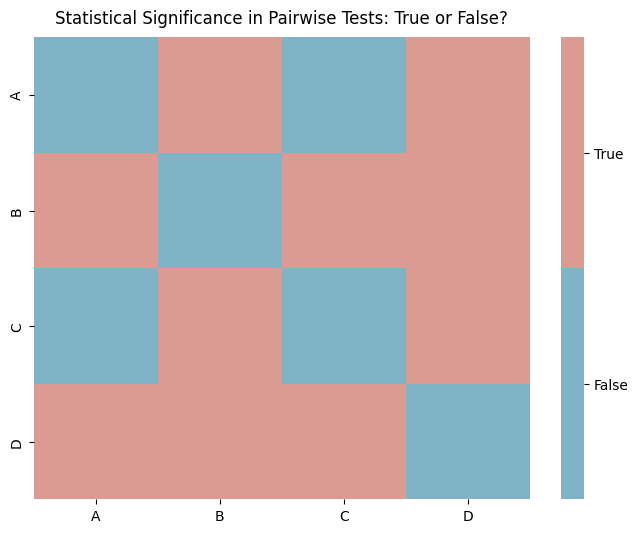

In [38]:
# Creating a Heatmap

# Empty DataFrame to store True/False results
# Iterating over the index (A, B, C, D)
versions = observed_values.index
stat_significant_df = pd.DataFrame(index=versions, columns=versions)

for i in versions:
    for j in versions:
        if i == j:
            stat_significant_df.loc[i, j] = False
        else:
            # Selecting the two rows to compare
            sub_table = observed_values.loc[[i, j]]
            chisq, pvalue, df, expected = chi2_contingency(sub_table, correction=False)

            # Storing whether the difference is significant
            stat_significant_df.loc[i, j] = pvalue < alpha_adj

# 4. Generating the heatmap
plt.figure(figsize=(8, 6))
# Convert to float/int so seaborn can process the colors
plot_data = stat_significant_df.astype(float)
color_palette = sns.diverging_palette(220, 20, n=2, s=50, l=70)

ax = sns.heatmap(plot_data, cmap=color_palette, annot=False)

# Customizing the colorbar
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([0.25, 0.75])
colorbar.set_ticklabels(['False', 'True'])

ax.set_title("Statistical Significance in Pairwise Tests: True or False?", pad=10)
plt.show()

Heatmap analysis reveals that the **Version C** with the highest click-through rate, exhibits a statistically significant difference when compared **Versions B and D**, but not to **Version A**, which possesses the second-highest click-through rate. As a result, declaring a clear winner based on post hoc tests becomes challenging, therefore we can only say that ***both Version C and Version A , the two white buttons are  equally good performers***.



### Alternative Approach: Standardised Residuals

**Pearson Residuals**
* Measure the difference between observed and expected counts
* Variance is slightly less than 1, so they don’t perfectly match the standard normal (Z) distribution
* Comparing them directly to Z-scores (e.g., ±1.96) is slightly inaccurate.

**Standardized (Adjusted) Residuals**
* Correct the variance issue of Pearson Residuals
* Calculated by dividing the Pearson Residual by an extra factor based on row and column totals
* Resulting residuals have variance = 1, perfectly matching the standard Z-distribution
* Allows for accurate comparison to Z-score thresholds

The formula for adjusted residue is:
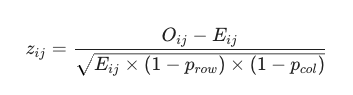


Where:
$O_{ij}$: Observed count in the cell.

$E_{ij}$: Expected count in the cell.

$p_{row}$: The proportion of the Total Row count relative to the Grand Total ($\frac{\text{Row Total}}{N}$).

$p_{col}$: The proportion of the Total Column count relative to the Grand Total ($\frac{\text{Col Total}}{N}$).



**Value Interpretation**

$> 1.96$      - Significant over-performance (at 95% confidence).

$< -1.96$     - Significant under-performance (at 95% confidence).

$> 2.58$      - Highly significant (at 99% confidence).

In [39]:
expected_value

array([[  382.48625502, 24943.51374498],
       [  373.74189974, 24373.25810026],
       [  375.69012397, 24500.30987603],
       [  381.08172127, 24851.91827873]])

In [40]:
observed_values

,Click,No_click
A,512,24814
B,281,24466
C,527,24349
D,193,25040


In [41]:
# Adding total (row-wise sum)
observed_values['total'] = observed_values['Click'] + observed_values['No_click']

# Add 'Total' row (Column-wise sum)
# We use .loc to append a new row named 'Total'
observed_values.loc['Total'] = observed_values.sum()

new=observed_values
new

,Click,No_click,total
A,512,24814,25326
B,281,24466,24747
C,527,24349,24876
D,193,25040,25233
Total,1513,98669,100182


In [42]:
# adding a new column with proportion
new["proportion"]=new["total"]/100182
new

,Click,No_click,total,proportion
A,512,24814,25326,0.252800
B,281,24466,24747,0.247020
C,527,24349,24876,0.248308
D,193,25040,25233,0.251872
Total,1513,98669,100182,1.000000


In [43]:
# we are considering only clicks  (& not No_clicks) of all version
P_row_A= 0.252800
P_row_B= 0.247020
P_row_C= 0.248308
P_row_D= 0.251872
P_col= 1513/100182

In [44]:
# z values

zA= (512-382.486)/math.sqrt((382.486)*(1-P_row_A)*(1-P_col))
zB= (281-373.742)/math.sqrt((373.742)*(1-P_row_B)*(1-P_col))
zC= (527-375.690)/math.sqrt((375.690)*(1-P_row_C)*(1-P_col))
zD= (193-381.082)/math.sqrt((381.082)*(1-P_row_C)*(1-P_col))
print (f" z values: \n A: {zA:.4f} \n B: {zB:.4f} \n C: {zC:.4f} \n D: {zD:.4f}")


 z values: 
 A: 7.7196 
 B: -5.5706 
 C: 9.0727 
 D: -11.1975


**Version A:**

  * Standardized Residual = +7.72
  * Far above the ±1.96 threshold → performance is extremely significant
  * About 8 standard deviations above the expected mean

**Version C:**
  * Standardized Residual = +9.07
  * Surpasses Version A → the ultimate champion statistically
  * Generated more raw clicks than expected despite slightly lower traffic


**Both versions crush the baseline expectation**

**Standardized Residuals capture not just volume, but efficiency relative to expectation**

**Version B:**
  * Standardized Residual = -5.57
  * Significantly below expectation – well below -1.96; underperforms moderately (fewer clicks than expected)

**Version D:**
  * Standardized Residual = -11.20
  * Extremely below expectation – largest negative residual; dramatic underperformer; much fewer clicks than expected

## **Further Analysis with other metrics**

After conducting the post-hoc tests, there is still no single clear winning variant.

The next steps could include running another experiment with the top-performing variants or analyzing additional metrics to better understand user behavior and make a more informed decision.

In this case, it was decided to examine **drop-off rate** and **homepage return rate** (as defined earlier). However, due to an error in the data collection process, these metrics were not available for Version B.

### Drop-Off Rate

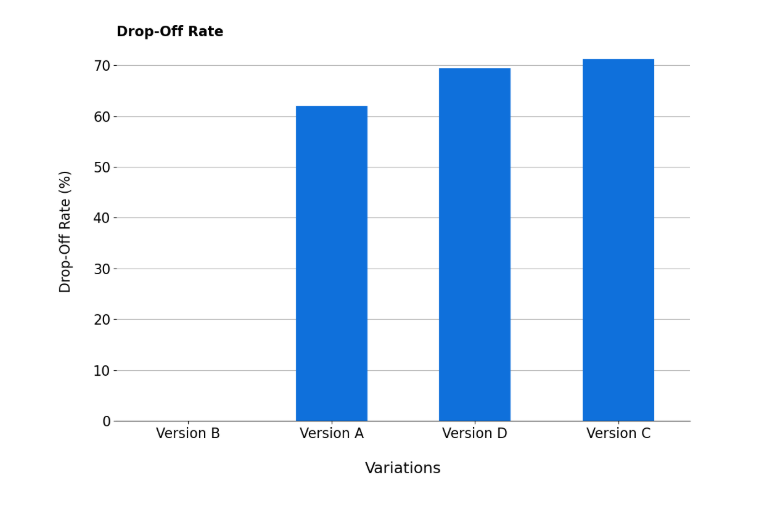

* Version A had the lowest Drop-off rate compared to D & C

### Homepage- Return Rate

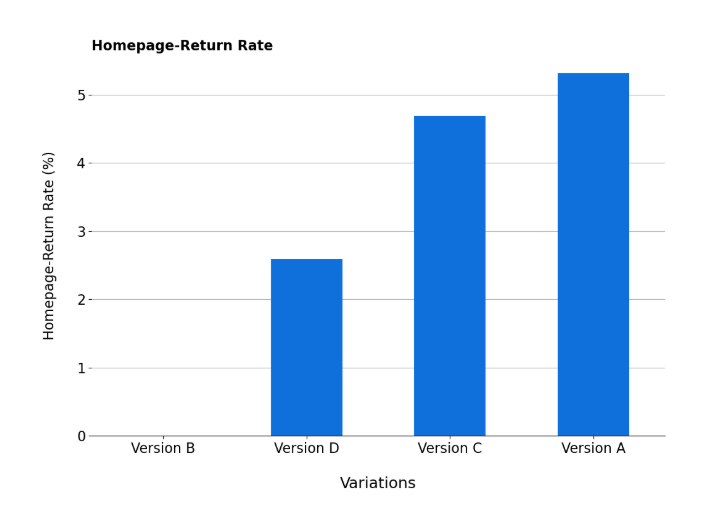

Version D had the lowest Homepage return rate

## **Observations**


* **Version A** seems to have high CTR (second to C with 2.02%), lower Drop-off rate (62%) but higher HRR (5.1%). Version A provides the best balance as it attracts a high volume of users and keeps them engaged better than other versions.

* **Version C** achieves the highest CTR (2.12%) but also has the highest drop-off rate (71%) and a moderate homepage-return rate (4.8%). While it attracts the most clicks, it struggles to retain users through the conversion funnel, suggesting that the button generates interest but the post-click experience fails to meet expectations.


* **Version D** has the lowest CTR (0.76%), higher Drop off rate (69%) & lowest HRR (2.7%).Version D is a "safe" bet for navigation, but its low volume makes it a poor choice for growth.

##**Conclusions**

If a definitive winner is required, additional steps beyond statistical analysis are needed. Some of the below actions can help in determining the best version :

* Consider other metrics alongside click-through rate.
* Incorporate qualitative research findings.
* Consult subject-matter experts.
* Redesign the experiment and conduct it once more.

